# Chapter 18: QSVT

---

**Prerequisites:**
- See `Chapter02_QuantumSoftware.ipynb` for installation instructions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import Chebyshev
from numpy.polynomial import Polynomial
from IPython.display import display
from scipy.sparse import diags
from pyqsp.angle_sequence import QuantumSignalProcessingPhases

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_ibm_runtime import Estimator
from qiskit_aer import Aer
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Statevector, Operator


from Chapter19_QSVT_functions import (SignalOperator, ShiftOperator, myQSVT,SunderhaufPolynomial)
                            

## Chebyshev polynomials

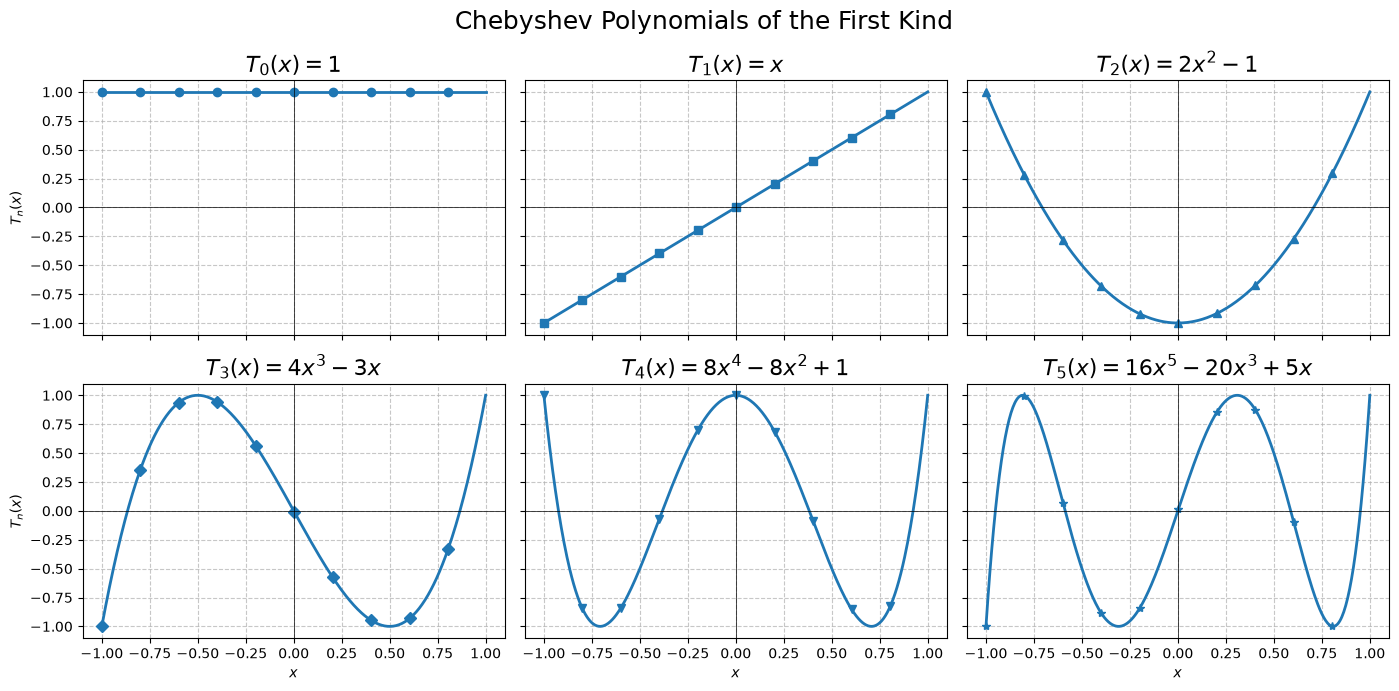

In [2]:
# Define the x range from -1 to 1
x = np.linspace(-1, 1, 400)

# Define the first 6 Chebyshev polynomials
T0 = np.ones_like(x)
T1 = x
T2 = 2*x**2 - 1
T3 = 4*x**3 - 3*x
T4 = 8*x**4 - 8*x**2 + 1
T5 = 16*x**5 - 20*x**3 + 5*x
# Plotting in separate subfigures
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)

polys = [
    (T0, r"$T_0(x)=1$", "o"),
    (T1, r"$T_1(x)=x$", "s"),
    (T2, r"$T_2(x)=2x^2-1$", "^"),
    (T3, r"$T_3(x)=4x^3-3x$", "D"),
    (T4, r"$T_4(x)=8x^4-8x^2+1$", "v"),
    (T5, r"$T_5(x)=16x^5-20x^3+5x$", "*"),
]

for ax, (T, label, marker) in zip(axes.flat, polys):
    ax.plot(x, T, linewidth=2, marker=marker, markevery=40, label=label)
    ax.set_title(label, fontsize=16)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_ylim(-1.1, 1.1)

for ax in axes[1, :]:
    ax.set_xlabel("$x$")
for ax in axes[:, 0]:
    ax.set_ylabel("$T_n(x)$")

fig.suptitle("Chebyshev Polynomials of the First Kind", fontsize=18)
plt.tight_layout()
plt.show()

## Sunderhauf approximation

Optimal degree: 53
Tau: 11.616488068919995


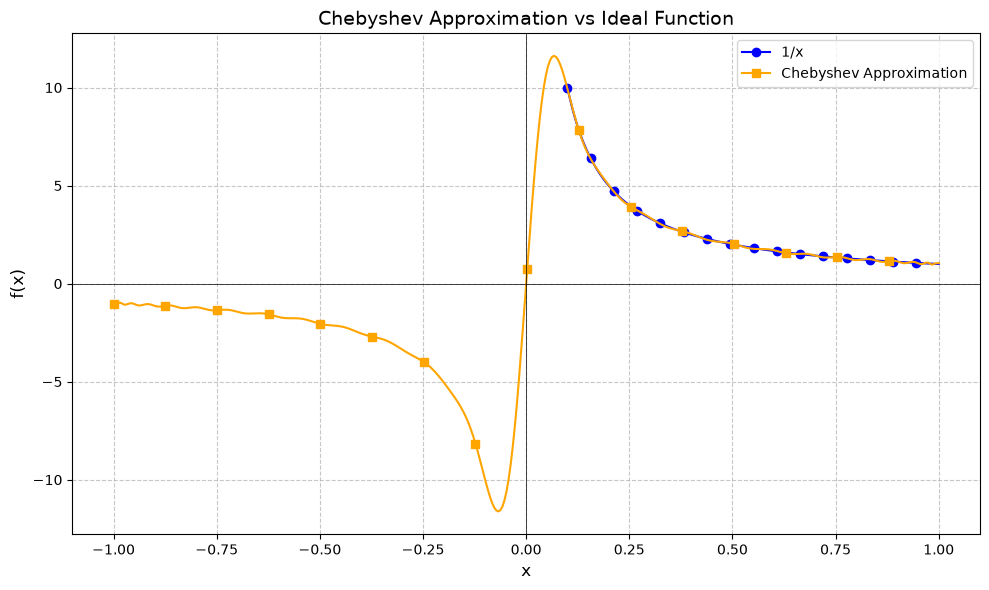

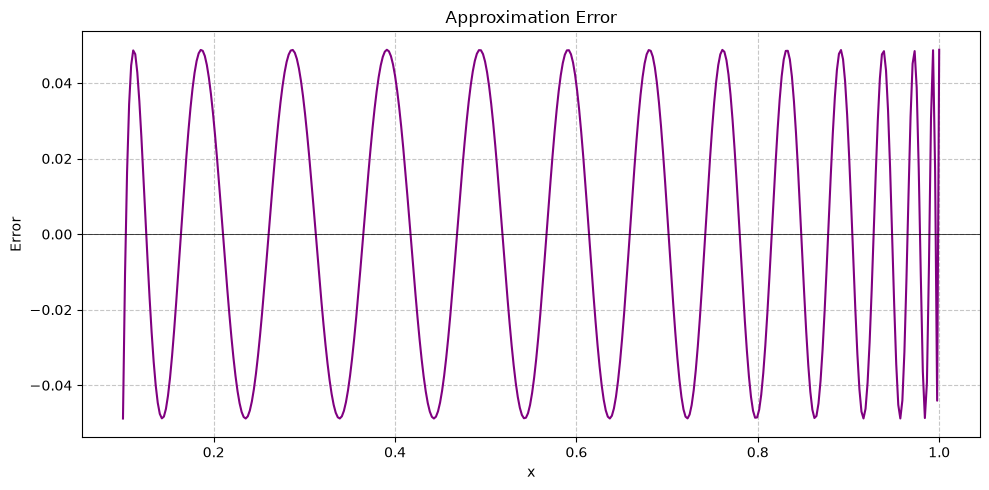

In [3]:
eps = 0.05
delta = 0.1

# Compute optimal degree
d = SunderhaufPolynomial.mindegree(eps, delta)
print(f"Optimal degree: {d}")  

# Get Chebyshev polynomial
cheb_poly = SunderhaufPolynomial.poly(d, delta)
cheb_poly_scaled = cheb_poly 

#print(f"Chebyshev polynomial\n", cheb_poly_scaled)

x = np.linspace(delta, 1, 400)
x_full = np.linspace(-1, 1, 400)
fx = 1/x
cheb_full = cheb_poly_scaled(x_full)
print(f"Tau: {np.max(np.abs(cheb_full))}")
plt.figure(figsize=(10, 6))
plt.plot(x, fx, label='1/x', color='blue', marker='o', markevery=25)
plt.plot(x_full, cheb_poly_scaled(x_full), label=f'Chebyshev Approximation', color='orange', marker='s', markevery=25)
plt.title('Chebyshev Approximation vs Ideal Function', fontsize=14) 
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.axhline(0, color='black', linewidth=0.5) # x
plt.axvline(0, color='black', linewidth=0.5) # y
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


error = cheb_poly_scaled(x) - fx


plt.figure(figsize=(10, 5))
plt.plot(x, error, label='Signed error: approx - desired', color='purple')
plt.title('Approximation Error')
plt.xlabel('x')
plt.ylabel('Error')
plt.axhline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### From Chebyshev to monomials

In [4]:
p_cheb = Chebyshev([1, 0, 0.5])
p_monomial = p_cheb.convert(kind=Polynomial)

# 3. Output the results
print(f"Chebyshev: {p_cheb}")
print(f"Monomial: {p_monomial}")
print(f"Monomial Coefficients: {p_monomial.coef}")


Chebyshev: 1.0 + 0.0 T_1(x) + 0.5 T_2(x)
Monomial: 0.5 + 0.0 x + 1.0 x**2
Monomial Coefficients: [0.5 0.  1. ]


### From Monomials to Chebyshev

In [5]:
# Convert from monomial (standard power basis) to Chebyshev basis
# Example: p(x) = 1 - 2x + 0.75x^2 - 0.5x^3
p_monomial = Polynomial([1.0, -2.0, 0.75, -0.5])
p_cheb = p_monomial.convert(kind=Chebyshev)

print(f"Monomial: {p_monomial}")
print(f"Chebyshev: {p_cheb}")
print(f"Chebyshev coefficients: {p_cheb.coef}")

Monomial: 1.0 - 2.0 x + 0.75 x**2 - 0.5 x**3
Chebyshev: 1.375 - 2.375 T_1(x) + 0.375 T_2(x) - 0.125 T_3(x)
Chebyshev coefficients: [ 1.375 -2.375  0.375 -0.125]


## Signal matrix

Degree: 4
x: 0.2
Chebyshev value: 0.6928
Coefficient of |0⟩: (0.6927999999999999+0j)


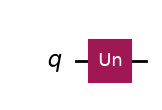

In [6]:
x = 0.2
n = 4
coeff = np.zeros(n+1)
coeff[n] = 1
p_cheb = Chebyshev(coeff)
p_cheb_value = p_cheb(x)
U = SignalOperator(x)
Un = np.linalg.matrix_power(U, n)
qc = QuantumCircuit(1)
qc.unitary(Un, 0,label='Un')
state = Statevector.from_instruction(qc)
amp_0 = state[0]
print(f'Degree: {n}')
print(f'x: {x}')
print(f"Chebyshev value: {p_cheb_value}")
print(f"Coefficient of |0⟩: {amp_0}")
display(qc.draw('mpl'))


## Numerically computing phase angles

In [7]:
cheb_coeffs = [0, 0, 0.5, 0, 0.1] 
poly = Chebyshev(cheb_coeffs)
phases= QuantumSignalProcessingPhases(poly)
print([round(float(phi), 3) for phi in phases])

[-1.517, 0.264, 0.008, 0.264, 0.054]


In [8]:
x = np.random.uniform(-1, 1)
print(f"Input x: {x:.4f}")
val = 0
for i, c in enumerate(cheb_coeffs):
    val += c * Chebyshev.basis(i)(x)
print(f"Chebyshev value: {val:.4f}")
U = SignalOperator(x)
S = ShiftOperator
W = S(phases[0])
for phi in phases[1:]:
    W = W @ U @ S(phi)
print("Re(Top-left entry):", np.real(np.round(W[0,0], 4)))



Input x: -0.7800
Chebyshev value: 0.0177
Re(Top-left entry): 0.0177


## Creating a quantum circuit for W

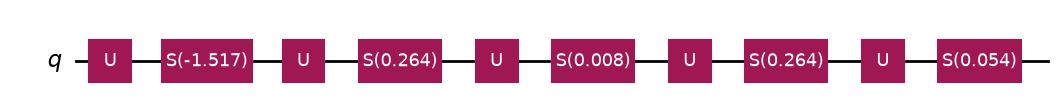

In [9]:
x= 0.5
cheb_coeffs = [0, 0, 0.5, 0, 0.1] 
poly = Chebyshev(cheb_coeffs)
phases= QuantumSignalProcessingPhases(poly)
qc = QuantumCircuit(1)
U = SignalOperator(x)
qc.unitary(U, 0, label='U')
S = ShiftOperator
phi = phases[0]
qc.unitary(S(phi), 0, label=f'S({phi:.3f})')
for phi in phases[1:]:
    qc.unitary(U, 0, label='U')
    qc.unitary(S(phi), 0, label=f'S({phi:.3f})')
display(qc.draw('mpl'))

## Eigen value decomposition

In [10]:
A = np.array([[0.1, 0.2], [0.2, 0.4]])
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Eigenvalues of A:", eigenvalues)
print("Eigenvectors of A:", eigenvectors)

Eigenvalues of A: [0.  0.5]
Eigenvectors of A: [[-0.89442719 -0.4472136 ]
 [ 0.4472136  -0.89442719]]


## Choose from Ax = b examples

In [11]:
example =2
if (example == 1):
	A = np.array([[1,0],[0,1]]) 
	b = np.array([1,0])
elif (example == 2):
	A = np.array([[2,-1],[-1,2]])
	b = np.array([1,1])/np.sqrt(2)
elif (example == 3):
	A = np.array([[1,0,0,-0.5],[0,1,0,0],[0,0,1,0],[-0.5,0,0,1]])
	b = np.array([1,0,0,0])
elif (example == 4):
	A = np.array([[1.5,0.5],[0.5,1.5]])
	b = np.array([1,0])
elif (example == 5):
	p = 2
	A = np.array([[5*(10**p),-1],[-1,5]])
	b = np.array([1,0])
elif (example == 6):
	N = 2**2
	values = [-np.ones(N-1),2*np.ones(N),-np.ones(N-1)]
	A = diags(values,[-1,0,1]).toarray()
	b = np.zeros(N)
	b[0] = 1

print("A:\n", A)
print("b:\n", b)

A:
 [[ 2 -1]
 [-1  2]]
b:
 [0.70710678 0.70710678]


## Solving

Singular values: [0.999001 0.333   ]
Optimal degree for ε=1.00e-02: 17
Polynomial maximum M = 3.611989
Max |p_norm| on [-1,1]: 0.998025
Generated 18 phase angles for degree 17
Circuit width: 4, depth: 37
Running statevector simulation...
Success probability |anc=0>: 0.738950
Eigenvalues of A: [1. 3.]
Condition number kappa=3.0
QSVT Solution (|x>): [0.70710678 0.70710678]
Classical Solution:  [0.70710678 0.70710678]
Fidelity:            0.9999999999999998


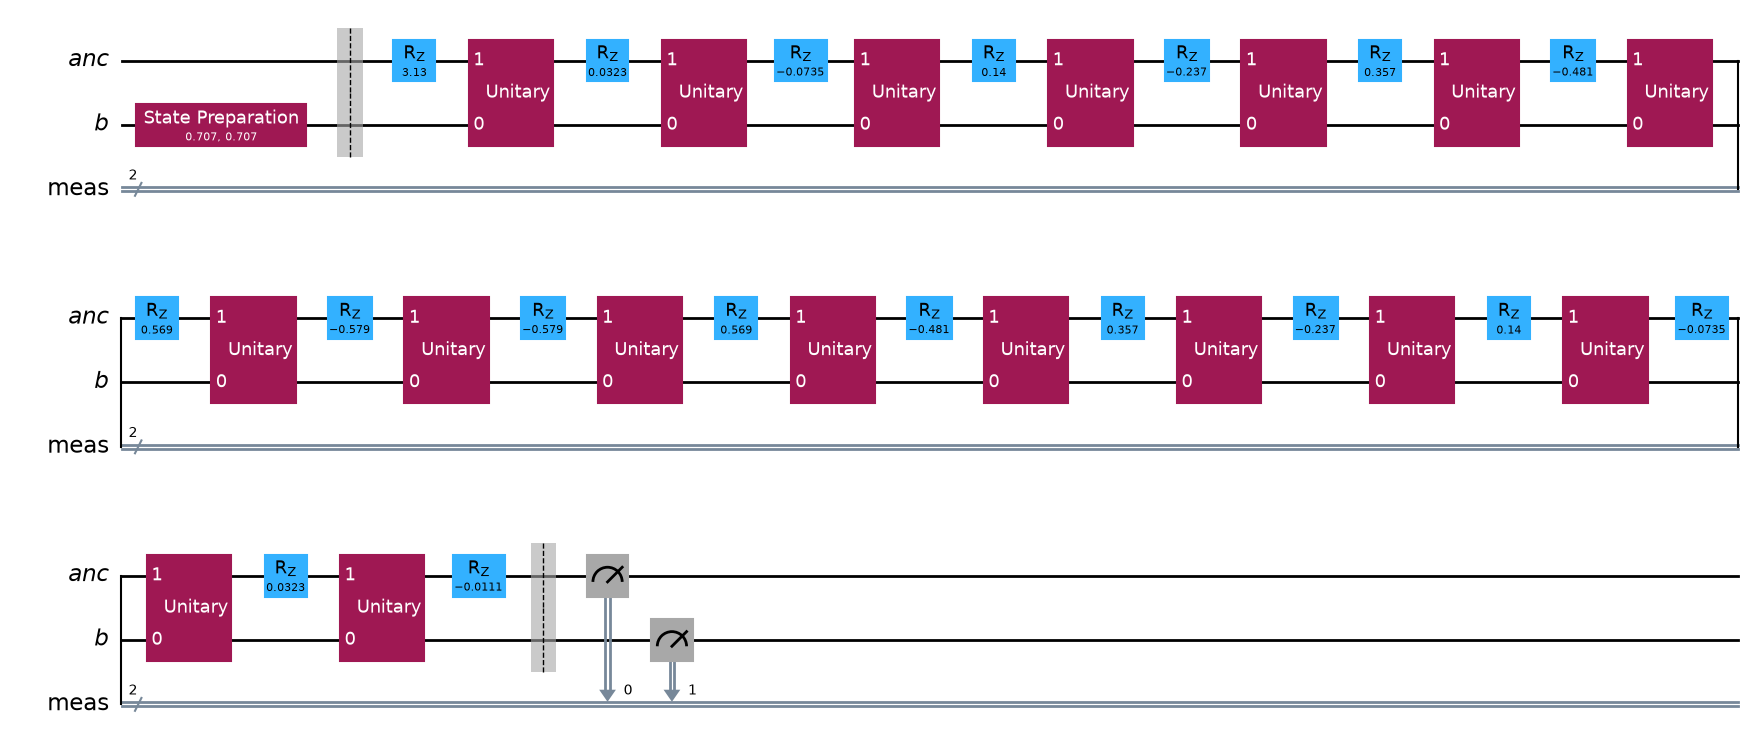

In [12]:

eigs_vals = np.linalg.eigvalsh(A)
A = A / (1.001*np.max(eigs_vals))  # Scale to have max eigenvalue = 1
kappa = np.max(eigs_vals) / np.min(eigs_vals)
solver = myQSVT(A, b, kappa, nShots=1000, target_error=0.01)
u_qsvt, info = solver.solve()

print("Eigenvalues of A:", eigs_vals)
print(f"Condition number kappa={kappa}")
print("QSVT Solution (|x>):", u_qsvt)
# Classical Verification
x_exact = np.linalg.solve(A, b)
u_exact = x_exact / np.linalg.norm(x_exact)
print("Classical Solution: ", u_exact)
print("Fidelity:           ", np.abs(np.dot(u_qsvt.conj(), u_exact))**2)

display(info['qc'].draw('mpl'))